# Data Preprocessing for Coding Agent

This notebook preprocesses the collected code samples for model training.

**Steps:**
1. Load raw data
2. Clean and validate
3. Tokenize code samples
4. Create train/validation/test splits
5. Save processed datasets

In [1]:
#!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

# Set up paths
RAW_DATA_DIR = Path('../data/raw')
PROCESSED_DATA_DIR = Path('../data/processed')
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Preprocessing environment ready!")

Preprocessing environment ready!


## 1. Load Raw Data

In [3]:
# Load data from JSON (better for code preservation)
data_path = RAW_DATA_DIR / 'code_samples.json'
df = pd.read_json(data_path)

print(f"Loaded {len(df)} samples")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst sample:")
print(df.iloc[0])

Loaded 13 samples

Columns: ['language', 'framework', 'description', 'code', 'context', 'category', 'id']

First sample:
language                                                  csharp
framework                                                dotnet8
description     Create a simple API controller with GET endpoint
code           using Microsoft.AspNetCore.Mvc;\n\nnamespace M...
context                    ASP.NET Core 8 minimal API controller
category                                              controller
id                                                             1
Name: 0, dtype: object


## 2. Data Cleaning and Validation

In [4]:
# Check for duplicates
duplicates = df.duplicated(subset=['code'], keep=False)
print(f"Duplicate code samples: {duplicates.sum()}")

# Remove duplicates
df = df.drop_duplicates(subset=['code'], keep='first')
print(f"Samples after removing duplicates: {len(df)}")

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Fill missing context with empty string
df['context'] = df['context'].fillna('')

# Remove samples with empty code
df = df[df['code'].str.strip() != '']
print(f"\nSamples after cleaning: {len(df)}")

Duplicate code samples: 0
Samples after removing duplicates: 13

Missing values:
language       0
framework      0
description    0
code           0
context        0
category       0
id             0
dtype: int64

Samples after cleaning: 13


## 3. Create Input-Output Pairs

Format data for training:
- **Input**: Description + Context
- **Output**: Code

In [5]:
def create_training_pair(row):
    """Create input-output pair for training"""
    # Input: description with language and framework context
    input_text = f"Language: {row['language']}\n"
    input_text += f"Framework: {row['framework']}\n"
    input_text += f"Task: {row['description']}\n"
    if row['context']:
        input_text += f"Context: {row['context']}\n"
    
    # Output: the code
    output_text = row['code']
    
    return input_text, output_text

# Create training pairs
df[['input', 'output']] = df.apply(
    lambda row: pd.Series(create_training_pair(row)), 
    axis=1
)

print("Sample training pair:")
print("\n=== INPUT ===")
print(df.iloc[0]['input'])
print("\n=== OUTPUT ===")
print(df.iloc[0]['output'])

Sample training pair:

=== INPUT ===
Language: csharp
Framework: dotnet8
Task: Create a simple API controller with GET endpoint
Context: ASP.NET Core 8 minimal API controller


=== OUTPUT ===
using Microsoft.AspNetCore.Mvc;

namespace MyApi.Controllers;

[ApiController]
[Route("api/[controller]")]
public class ProductsController : ControllerBase
{
    [HttpGet]
    public IActionResult GetAll()
    {
        return Ok(new { message = "Products retrieved successfully" });
    }
}


## 4. Initialize Tokenizer

Using CodeBERT tokenizer for code-aware tokenization

In [6]:
# Load pre-trained tokenizer
model_name = "microsoft/codebert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Loaded tokenizer: {model_name}")
print(f"Vocabulary size: {tokenizer.vocab_size}")

# Test tokenization
sample_code = df.iloc[0]['output']
tokens = tokenizer.tokenize(sample_code)
print(f"\nSample tokenization (first 20 tokens):")
print(tokens[:20])

Loaded tokenizer: microsoft/codebert-base
Vocabulary size: 50265

Sample tokenization (first 20 tokens):
['using', 'ĠMicrosoft', '.', 'As', 'p', 'Net', 'Core', '.', 'M', 'vc', ';', 'Ċ', 'Ċ', 'names', 'pace', 'ĠMy', 'A', 'pi', '.', 'Cont']


## 5. Analyze Token Lengths

Token length statistics:
       input_tokens  output_tokens  total_tokens
count     13.000000      13.000000     13.000000
mean      32.923077     211.846154    244.769231
std        2.325996     124.952555    124.465627
min       30.000000      36.000000     70.000000
25%       31.000000     130.000000    164.000000
50%       33.000000     199.000000    231.000000
75%       34.000000     231.000000    266.000000
max       37.000000     475.000000    507.000000


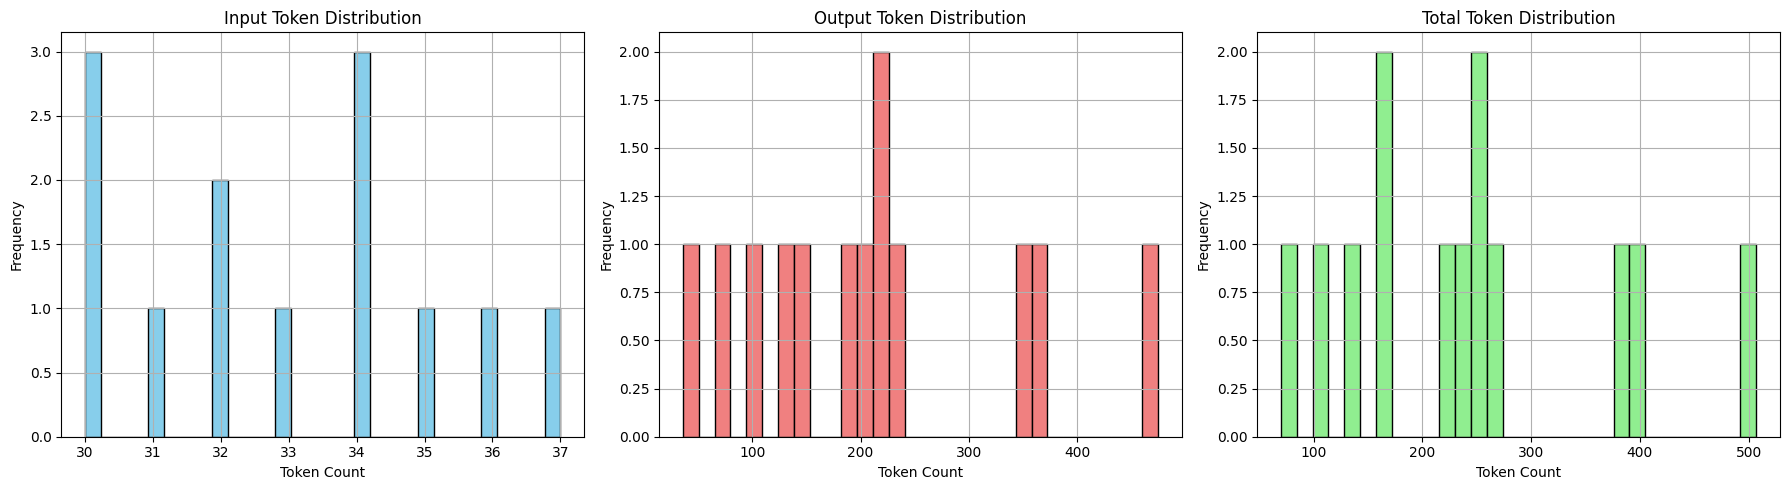


Recommended max sequence length (95th percentile): 443


In [7]:
# Calculate token lengths
def get_token_length(text):
    return len(tokenizer.encode(text, add_special_tokens=True))

df['input_tokens'] = df['input'].apply(get_token_length)
df['output_tokens'] = df['output'].apply(get_token_length)
df['total_tokens'] = df['input_tokens'] + df['output_tokens']

print("Token length statistics:")
print(df[['input_tokens', 'output_tokens', 'total_tokens']].describe())

# Visualize token distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['input_tokens'].hist(bins=30, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Input Token Distribution')
axes[0].set_xlabel('Token Count')
axes[0].set_ylabel('Frequency')

df['output_tokens'].hist(bins=30, ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Output Token Distribution')
axes[1].set_xlabel('Token Count')
axes[1].set_ylabel('Frequency')

df['total_tokens'].hist(bins=30, ax=axes[2], color='lightgreen', edgecolor='black')
axes[2].set_title('Total Token Distribution')
axes[2].set_xlabel('Token Count')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Set max sequence length based on data
max_seq_length = int(df['total_tokens'].quantile(0.95))
print(f"\nRecommended max sequence length (95th percentile): {max_seq_length}")

## 6. Create Train/Validation/Test Splits

In [8]:
# Split ratios: 70% train, 15% validation, 15% test
from sklearn.model_selection import train_test_split
import numpy as np

try:
    # First split (Train vs Temp)
    train_df, temp_df = train_test_split(
        df, 
        test_size=0.3, 
        random_state=42, 
        stratify=df['language']
    )
    
    # Second split (Val vs Test)
    # Check if we can stratify: all classes in temp_df must have at least 2 members
    class_counts = temp_df['language'].value_counts()
    if (class_counts >= 2).all():
        val_df, test_df = train_test_split(
            temp_df, 
            test_size=0.5, 
            random_state=42, 
            stratify=temp_df['language']
        )
    else:
        print("Warning: Insufficient samples for stratified Val/Test split. Falling back to random split.")
        val_df, test_df = train_test_split(
            temp_df, 
            test_size=0.5, 
            random_state=42
        )
except ValueError as e:
    print(f"Stratification failed: {e}. Falling back to random splits.")
    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

# Verify distribution
print("\nLanguage distribution in splits:")
print("\nTrain:")
print(train_df['language'].value_counts())
print("\nValidation:")
print(val_df['language'].value_counts())
print("\nTest:")
print(test_df['language'].value_counts())

# Handle edge cases for extremely small datasets
if len(val_df) == 0 or len(test_df) == 0:
    print("\nCRITICAL WARNING: Empty splits detected. Adjusting manually.")
    indices = np.random.permutation(len(df))
    train_end = int(0.7 * len(df))
    val_end = int(0.85 * len(df))
    train_df = df.iloc[indices[:train_end]]
    val_df = df.iloc[indices[train_end:val_end]]
    test_df = df.iloc[indices[val_end:]]

Train samples: 9
Validation samples: 2
Test samples: 2

Language distribution in splits:

Train:
language
csharp        3
typescript    3
sql           3
Name: count, dtype: int64

Validation:
language
typescript    1
sql           1
Name: count, dtype: int64

Test:
language
sql       1
csharp    1
Name: count, dtype: int64


## 7. Save Processed Datasets

In [9]:
# Select relevant columns for training
columns_to_save = ['language', 'framework', 'category', 'description', 'context', 'input', 'output']

# Save as JSON
train_df[columns_to_save].to_json(
    PROCESSED_DATA_DIR / 'train.json', 
    orient='records', 
    indent=2
)
val_df[columns_to_save].to_json(
    PROCESSED_DATA_DIR / 'validation.json', 
    orient='records', 
    indent=2
)
test_df[columns_to_save].to_json(
    PROCESSED_DATA_DIR / 'test.json', 
    orient='records', 
    indent=2
)

print("Datasets saved to:")
print(f"  - {PROCESSED_DATA_DIR / 'train.json'}")
print(f"  - {PROCESSED_DATA_DIR / 'validation.json'}")
print(f"  - {PROCESSED_DATA_DIR / 'test.json'}")

# Save metadata
metadata = {
    'total_samples': len(df),
    'train_samples': len(train_df),
    'val_samples': len(val_df),
    'test_samples': len(test_df),
    'max_seq_length': max_seq_length,
    'tokenizer': model_name,
    'languages': df['language'].unique().tolist(),
    'frameworks': df['framework'].unique().tolist(),
    'categories': df['category'].unique().tolist()
}

with open(PROCESSED_DATA_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\nMetadata saved to: {PROCESSED_DATA_DIR / 'metadata.json'}")

Datasets saved to:
  - ..\data\processed\train.json
  - ..\data\processed\validation.json
  - ..\data\processed\test.json

Metadata saved to: ..\data\processed\metadata.json


## 8. Data Summary and Visualization

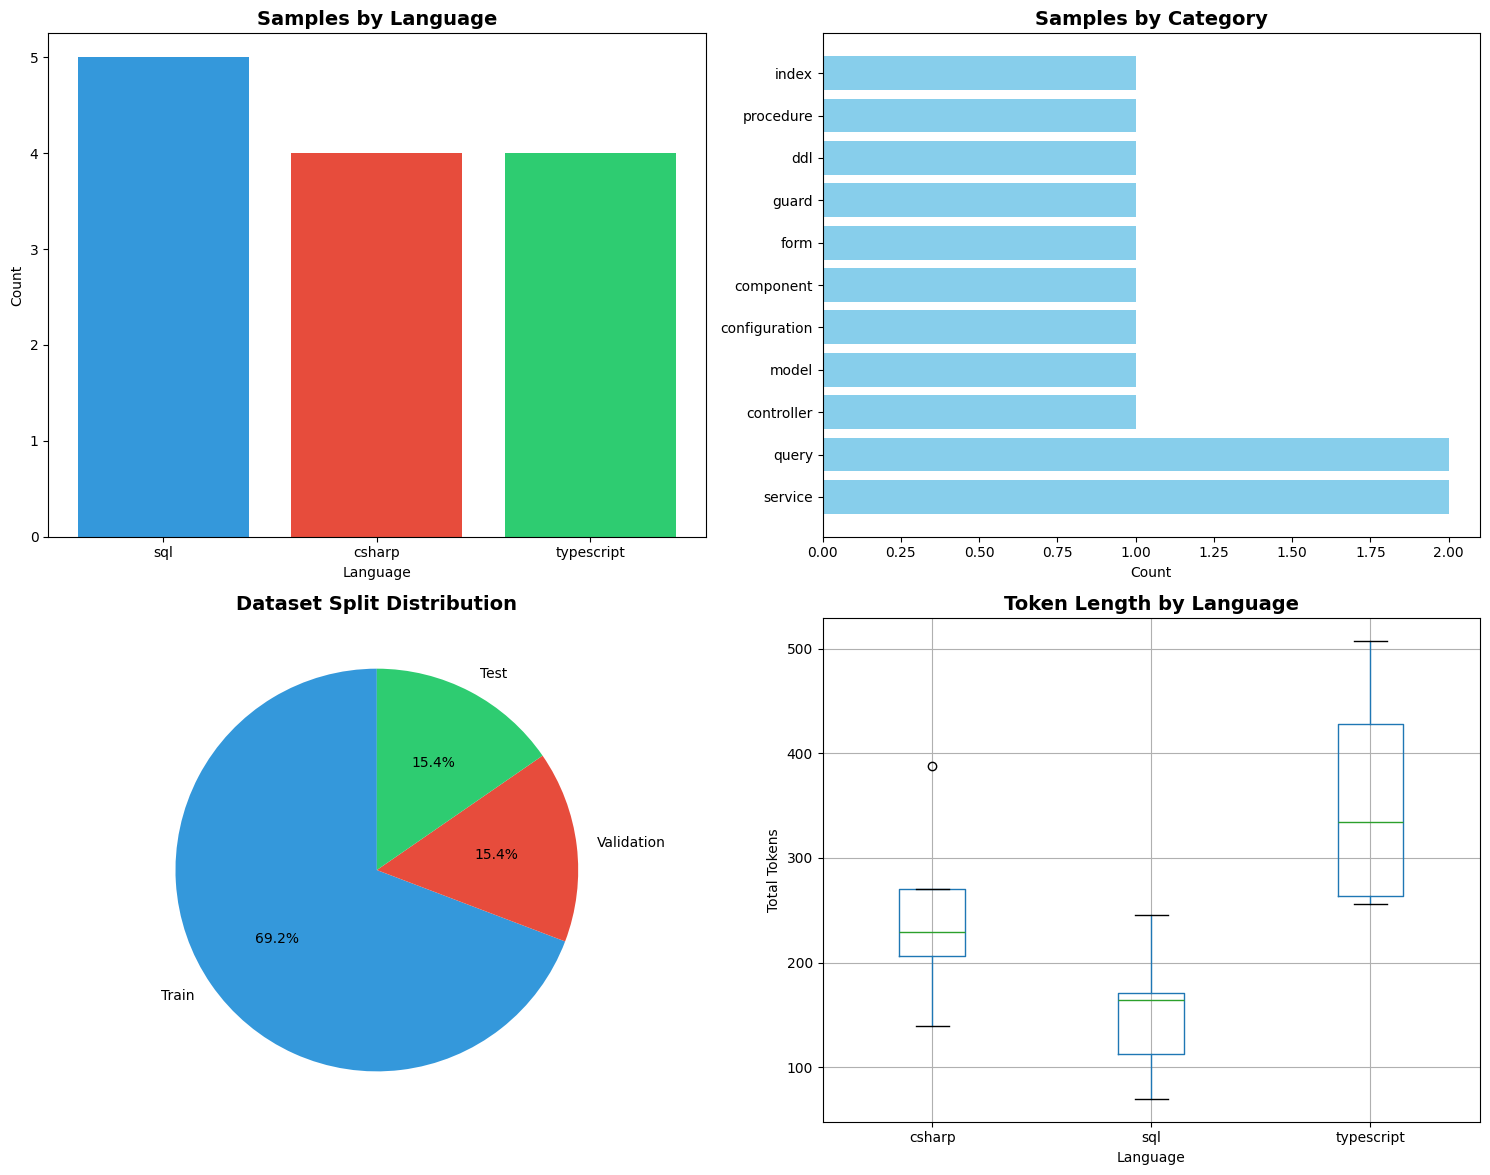


DATA PREPROCESSING COMPLETE!

Total samples processed: 13
Ready for training: 9 samples

Next step: Run notebook 03_model_architecture.ipynb


In [10]:
# Create summary visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Language distribution
language_counts = df['language'].value_counts()
axes[0, 0].bar(language_counts.index, language_counts.values, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0, 0].set_title('Samples by Language', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Language')
axes[0, 0].set_ylabel('Count')

# Category distribution
category_counts = df['category'].value_counts()
axes[0, 1].barh(category_counts.index, category_counts.values, color='skyblue')
axes[0, 1].set_title('Samples by Category', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Count')

# Split distribution
split_data = ['Train', 'Validation', 'Test']
split_counts = [len(train_df), len(val_df), len(test_df)]
axes[1, 0].pie(split_counts, labels=split_data, autopct='%1.1f%%', startangle=90, 
               colors=['#3498db', '#e74c3c', '#2ecc71'])
axes[1, 0].set_title('Dataset Split Distribution', fontsize=14, fontweight='bold')

# Token length box plot by language
df.boxplot(column='total_tokens', by='language', ax=axes[1, 1])
axes[1, 1].set_title('Token Length by Language', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Language')
axes[1, 1].set_ylabel('Total Tokens')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("DATA PREPROCESSING COMPLETE!")
print("="*50)
print(f"\nTotal samples processed: {len(df)}")
print(f"Ready for training: {len(train_df)} samples")
print(f"\nNext step: Run notebook 03_model_architecture.ipynb")